# Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
import re

# Import Database

In [2]:
database = 'Processability and Product Properties Data Library of scl-PHAs_2nd upload_V03.xlsx'

# Create DataFrames for each type of properties

In [3]:
# Physicochemical properties DataFrame
df_physicochem = pd.read_excel(database, sheet_name='Physchem_properties')

# Mechanical properties DataFrame
df_mech = pd.read_excel(database, sheet_name='Mechanical_properties')

# Thermal properties DataFrame
df_therm = pd.read_excel(database, sheet_name='Thermal_properties')

# Process Physicochemical properties DataFrame

In [4]:
# Check for columns names and null values
df_physicochem.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 22 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Study_id                                 598 non-null    int64  
 1   Instance                                 598 non-null    int64  
 2   Monomer_A                                593 non-null    object 
 3   Monomer_B                                585 non-null    object 
 4   HB_ratio (mol%)                          595 non-null    float64
 5   HV_ratio (mol%)                          595 non-null    float64
 6   Mw_PHBV                                  346 non-null    float64
 7   Mn_PHBV                                  144 non-null    float64
 8   Density                                  110 non-null    float64
 9   Density_units                            110 non-null    object 
 10  PDI                                      179 non-n

In [5]:
df_therm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Study_id           598 non-null    int64  
 1   Instance           598 non-null    int64  
 2   Tg1                257 non-null    float64
 3   Tg2                20 non-null     float64
 4   Tc1                319 non-null    float64
 5   Tc2                5 non-null      float64
 6   Tmc                49 non-null     float64
 7   Tm1                525 non-null    float64
 8   Tm2                192 non-null    float64
 9   Td5                202 non-null    float64
 10  Tdeg               101 non-null    float64
 11  Temperature_units  565 non-null    object 
 12  DHm1               341 non-null    float64
 13  DHm2               38 non-null     float64
 14  DHc1               179 non-null    float64
 15  DHc2               7 non-null      float64
 16  Enthaply_units     333 non

In [6]:
# Process Mw, Mn and PDI columns
# PDI = Mw/Mn

mask_Mw = (
    df_physicochem['Mw_PHBV'].isna() &
    df_physicochem['Mn_PHBV'].notna() &
    df_physicochem['PDI'].notna()
)

mask_Mn = (
    df_physicochem['Mn_PHBV'].isna() &
    df_physicochem['Mw_PHBV'].notna() &
    df_physicochem['PDI'].notna()
)

mask_PDI = (
    df_physicochem['PDI'].isna() &
    df_physicochem['Mw_PHBV'].notna() &
    df_physicochem['Mn_PHBV'].notna()
)


df_physicochem.loc[mask_Mw, 'Mw_PHBV'] = (
    df_physicochem.loc[mask_Mw, 'PDI'] * df_physicochem.loc[mask_Mw, 'Mn_PHBV']
)

df_physicochem.loc[mask_Mn, 'Mn_PHBV'] = (
    df_physicochem.loc[mask_Mn, 'Mw_PHBV'] / df_physicochem.loc[mask_Mn, 'PDI']
)

df_physicochem.loc[mask_PDI, 'PDI'] = (
    df_physicochem.loc[mask_PDI, 'Mw_PHBV'] / df_physicochem.loc[mask_PDI, 'Mn_PHBV']
)

In [9]:
df_physicochem.columns

Index(['Study_id', 'Instance', 'Monomer_A', 'Monomer_B', 'HB_ratio (mol%)',
       'HV_ratio (mol%)', 'Mw_PHBV', 'Mn_PHBV', 'Density', 'Density_units',
       'PDI', 'Additive1', 'Additive1_type', 'Additive1_name',
       'Additive1_percentage (wt%)', 'Additive2', 'Additive2_type',
       'Additive2_name', 'Additive2_percentage (wt%)',
       'final_formulation_PHBV_percentage (wt%)', 'Unnamed: 20', 'Row No'],
      dtype='object')

In [10]:
# Categorical columns to fill with 'not_applicable'
categorical_cols = ['Additive1_type', 'Additive2_type']

# Numerical columns to fill with 0
numeric_cols = ['Additive1_percentage (wt%)', 'Additive2_percentage (wt%)']

# Fill categorical columns
for col in categorical_cols:
    df_physicochem[col] = df_physicochem[col].fillna('no_additive').astype(str)

# Fill numerical columns
for col in numeric_cols:
    df_physicochem[col] = df_physicochem[col].fillna(0)

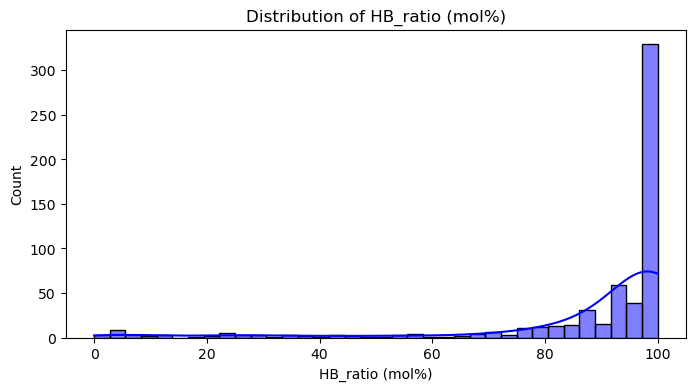

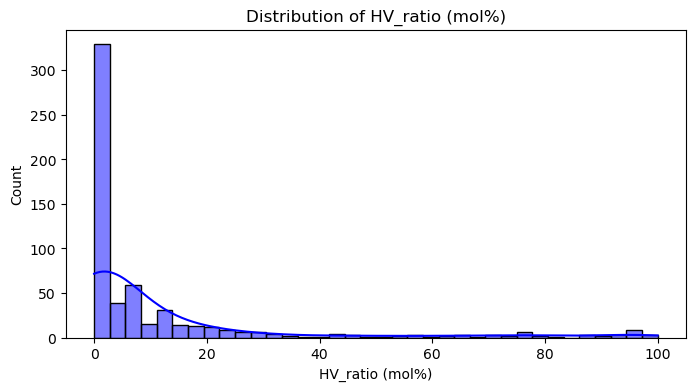

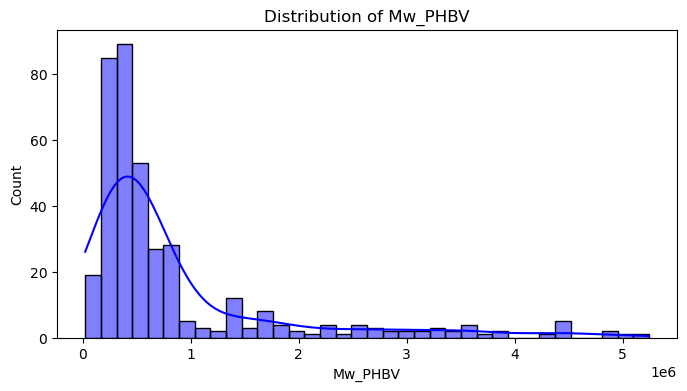

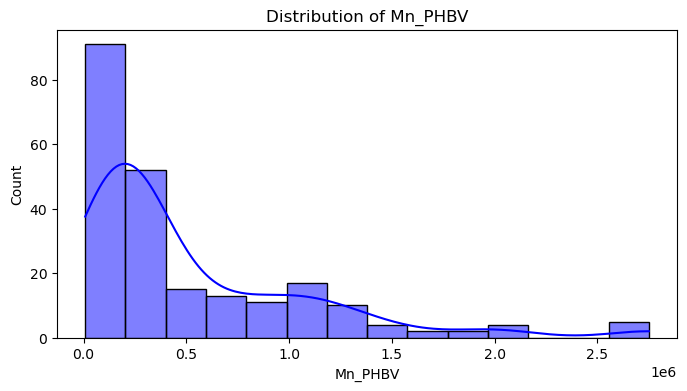

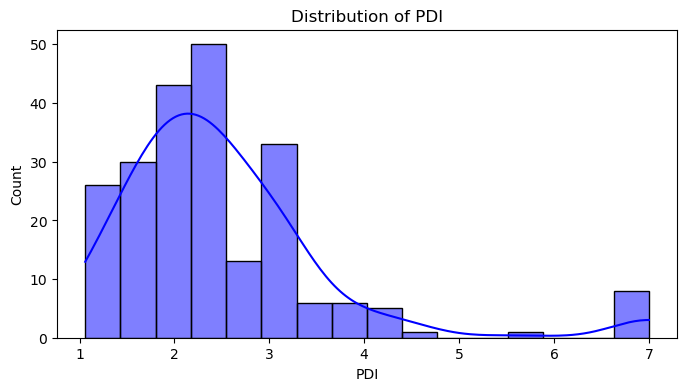

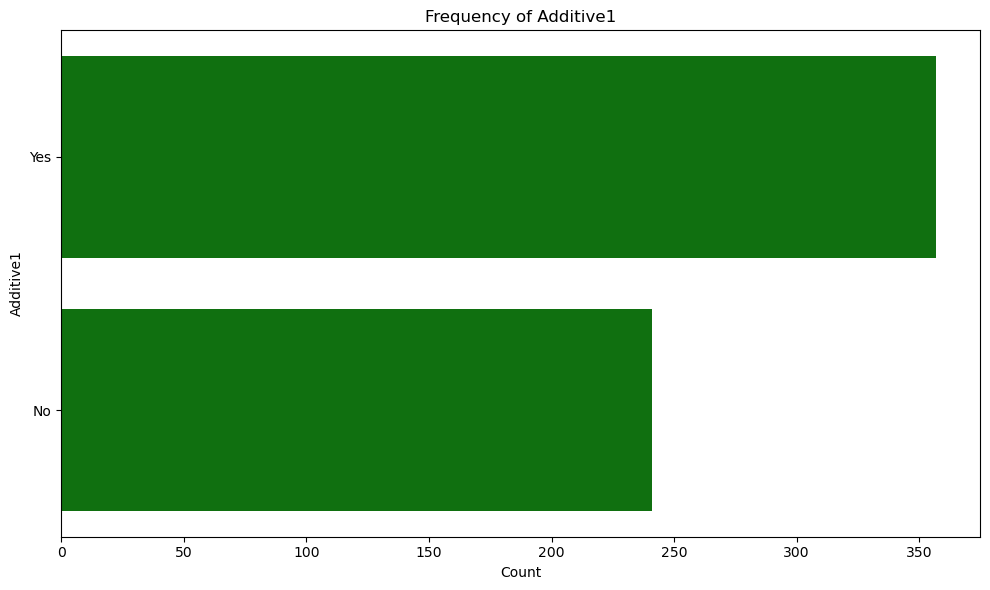

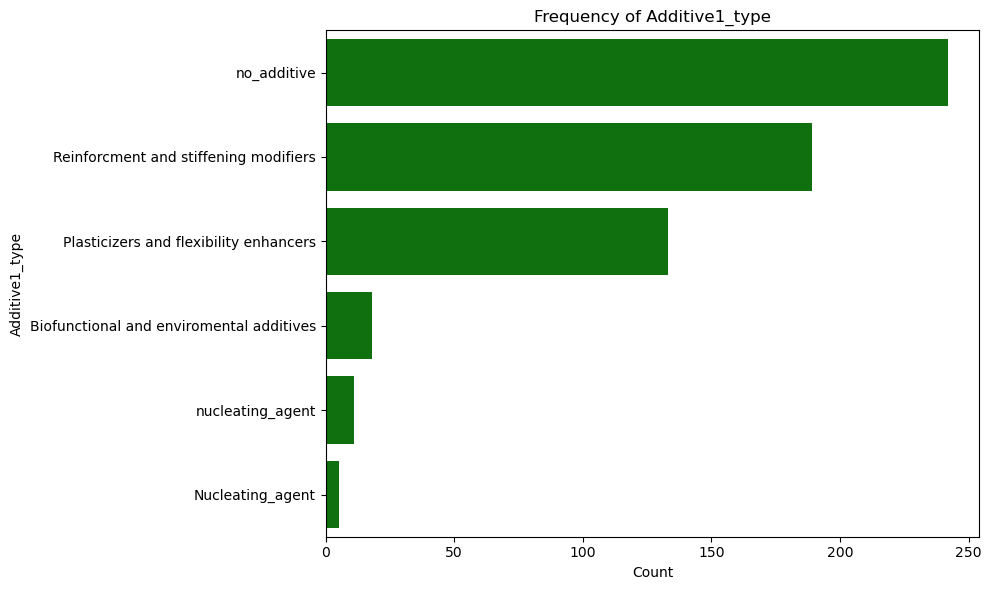

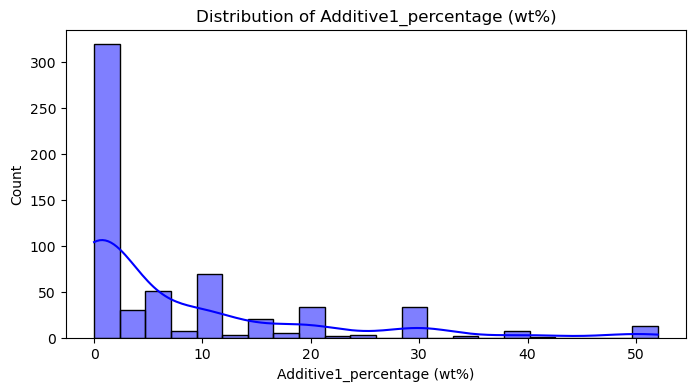

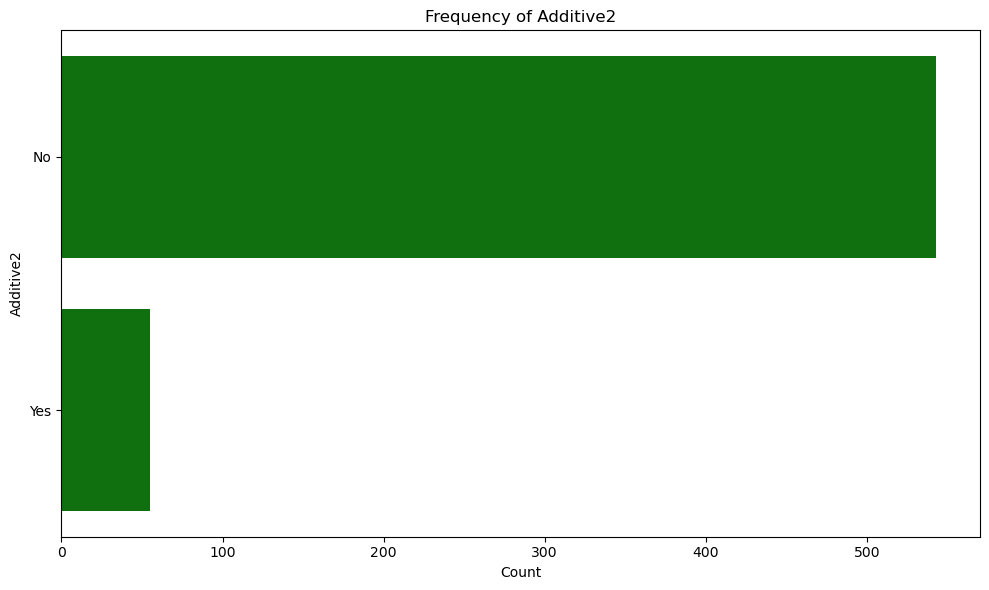

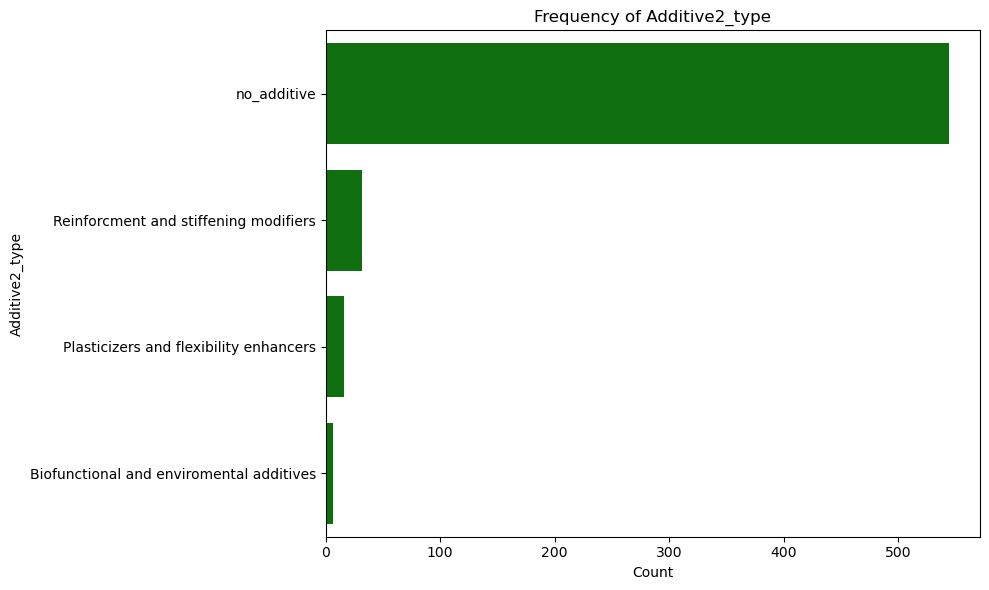

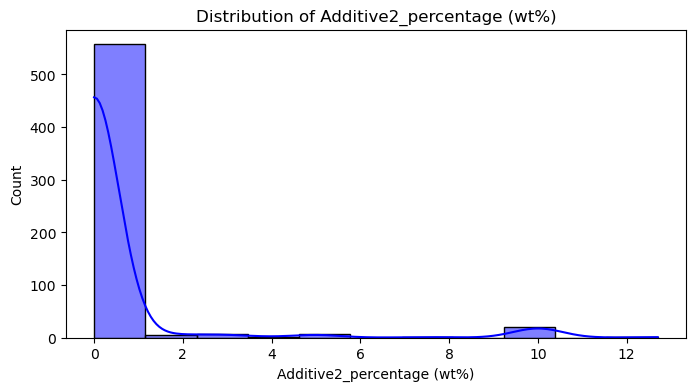

In [11]:
# Make diagrams of distribution for numerical data (blue color) and frequency for categorical data (green color)

phys_col = ['HB_ratio (mol%)', 'HV_ratio (mol%)', 'Mw_PHBV', 'Mn_PHBV', 'PDI', 'Additive1', 'Additive1_type', 'Additive1_percentage (wt%)', 'Additive2', 'Additive2_type', 'Additive2_percentage (wt%)']

for col in phys_col:
    if pd.api.types.is_numeric_dtype(df_physicochem[col]):
        plt.figure(figsize=(8, 4))
        sns.histplot(df_physicochem[col], kde=True, color='blue')
        plt.title(f'Distribution of {col}')
    else:
        # Count number of unique categories for dynamic figure height
        num_categories = df_physicochem[col].nunique()
        fig_height = max(6, num_categories * 0.25)

        plt.figure(figsize=(10, fig_height))  # Wider and taller figure
        order = df_physicochem[col].value_counts().index  # Sort by frequency
        sns.countplot(y=col, data=df_physicochem, order=order, color='green')

        plt.title(f'Frequency of {col}')
        plt.xlabel('Count')
        plt.ylabel(col)
        plt.tight_layout()

    plt.show()

# Process Thermal properties DataFrame

In [12]:
# Check for columns names and null values
df_therm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Study_id           598 non-null    int64  
 1   Instance           598 non-null    int64  
 2   Tg1                257 non-null    float64
 3   Tg2                20 non-null     float64
 4   Tc1                319 non-null    float64
 5   Tc2                5 non-null      float64
 6   Tmc                49 non-null     float64
 7   Tm1                525 non-null    float64
 8   Tm2                192 non-null    float64
 9   Td5                202 non-null    float64
 10  Tdeg               101 non-null    float64
 11  Temperature_units  565 non-null    object 
 12  DHm1               341 non-null    float64
 13  DHm2               38 non-null     float64
 14  DHc1               179 non-null    float64
 15  DHc2               7 non-null      float64
 16  Enthaply_units     333 non

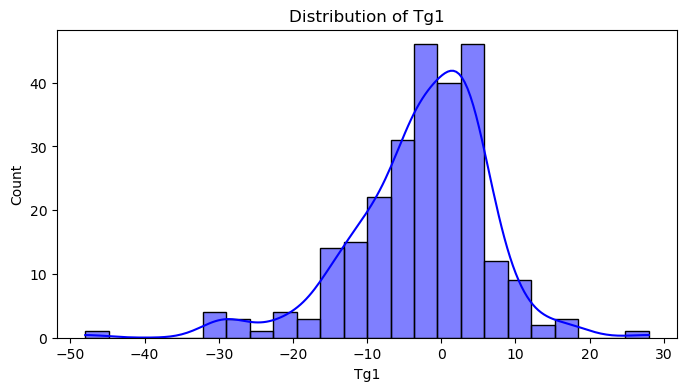

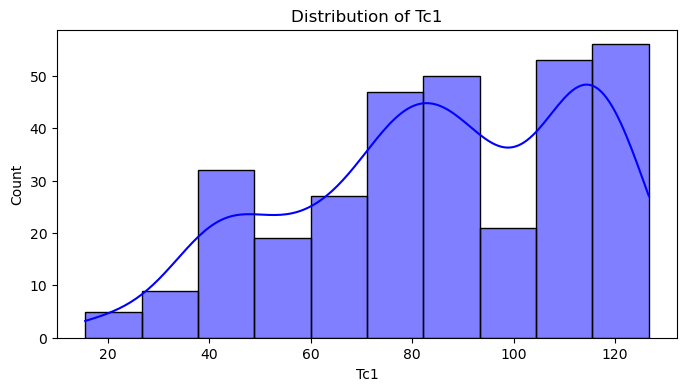

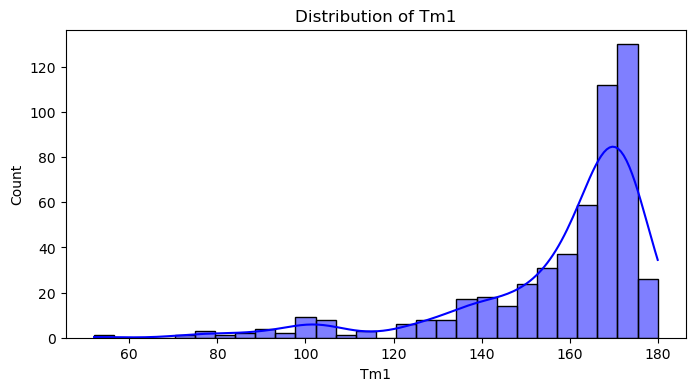

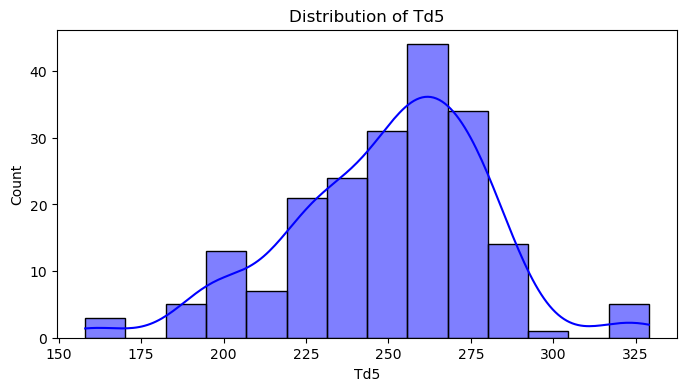

In [13]:
# Make diagrams of distribution for numerical data (blue color) and frequency for categorical data (green color)

therm_col = ['Tg1', 'Tc1', 'Tm1', 'Td5']

for col in therm_col:
    if pd.api.types.is_numeric_dtype(df_therm[col]):
        plt.figure(figsize=(8, 4))
        sns.histplot(df_therm[col], kde=True, color='blue')
        plt.title(f'Distribution of {col}')
    else:
        # Count number of unique categories for dynamic figure height
        num_categories = df_therm[col].nunique()
        fig_height = max(6, num_categories * 0.25)

        plt.figure(figsize=(10, fig_height))  # Wider and taller figure
        order = df_therm[col].value_counts().index  # Sort by frequency
        sns.countplot(y=col, data=df_therm, order=order, color='green')

        plt.title(f'Frequency of {col}')
        plt.xlabel('Count')
        plt.ylabel(col)
        plt.tight_layout()

    plt.show()

# Process Mechanical properties DataFrame

In [14]:
# Check for columns names and null values
df_mech.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Study_id             598 non-null    int64  
 1   Instance             598 non-null    int64  
 2   ISO                  64 non-null     object 
 3   ASTM                 98 non-null     object 
 4   T_mech               118 non-null    float64
 5   T_mech_units         118 non-null    object 
 6   Spread_speed         196 non-null    float64
 7   Spread_units         196 non-null    object 
 8   Morphology           156 non-null    object 
 9   Size_diameter        18 non-null     float64
 10  Size_length          133 non-null    float64
 11  Size_width           137 non-null    float64
 12  Size_thickness       88 non-null     float64
 13  Size_units           161 non-null    object 
 14  Young_modulus        294 non-null    float64
 15  Tensile_strength     275 non-null    flo

In [15]:
# Check Mechanical_units
df_mech['Mechanical_units'].unique()

array(['Mpa', nan, 'kgf/mm^2', 'N/mm^2'], dtype=object)

In [16]:
# Conversion factors to MPa
unit_conversion = {
    'N/mm^2': 1.0,              # 1 N/mm² = 1 MPa
    'kgf/mm^2': 1 / 9.80665,    # 1 kgf/mm² ≈ 9.80665 MPa
    'Gpa': 1000.0               # 1 GPa = 1000 MPa
}

# Mechanical property columns to convert
mech_cols = ['Young_modulus', 'Tensile_strength', 'Stress_at_break', 'Yield_strength', 'Elongation_at_break']

# Apply vectorized conversion
for unit, factor in unit_conversion.items():
    mask = df_mech['Mechanical_units'] == unit

    for col in mech_cols:
        # Apply only to non-null values
        df_mech.loc[mask & df_mech[col].notna(), col] = (
            df_mech.loc[mask & df_mech[col].notna(), col] / factor
        )

# After conversions, update Mechanical_units to 'Mpa'
df_mech.loc[df_mech['Mechanical_units'].isin(unit_conversion.keys()), 'Mechanical_units'] = 'Mpa'

In [17]:
# Check Size_units
df_mech['Size_units'].unique()

array(['μm', nan, 'mm', 'nm'], dtype=object)

In [18]:
# Conversion factors to mm
size_unit_conversion = {
    'nm': 1e-6,     # nanometers to mm
    'μm': 1e-3,     # micrometers to mm
    'mm': 1.0,      # millimeters to mm
    'cm': 10.0,     # centimeters to mm
    'in': 25.4      # inches to mm
}

# Column(s) that store size values
size_cols = ['Size_diameter', 'Size_length', 'Size_width', 'Size_thickness']  # adjust if you have more columns to convert

# Apply conversion
for unit, factor in size_unit_conversion.items():
    mask = df_mech['Size_units'] == unit

    for col in size_cols:
        df_mech.loc[mask & df_mech[col].notna(), col] = (
            df_mech.loc[mask & df_mech[col].notna(), col] * factor
        )

# After conversions, update the unit column to 'mm'
df_mech.loc[df_mech['Size_units'].isin(size_unit_conversion.keys()), 'Size_units'] = 'mm'

In [19]:
# Check Spread_units
df_mech['Spread_units'].unique()

array([nan, 'mm/min', 'mm/s'], dtype=object)

In [20]:
# Conversion factors to mm/min
rate_unit_conversion = {
    'mm/s': 60.0,   # 1 mm/s = 60 mm/min
    'mm/min': 1.0   # already in mm/min
}

# Column(s) that store rate values (e.g., crosshead speed)
rate_cols = ['Spread_speed']  # adjust if your column name is different

# Apply conversion
for unit, factor in rate_unit_conversion.items():
    mask = df_mech['Spread_units'] == unit

    for col in rate_cols:
        df_mech.loc[mask & df_mech[col].notna(), col] = (
            df_mech.loc[mask & df_mech[col].notna(), col] * factor
        )

# After conversions, update unit column to 'mm/min'
df_mech.loc[df_mech['Spread_units'].isin(rate_unit_conversion.keys()), 'Spread_units'] = 'mm/min'


In [21]:
df_mech.columns

Index(['Study_id', 'Instance', 'ISO', 'ASTM', 'T_mech', 'T_mech_units',
       'Spread_speed', 'Spread_units', 'Morphology', 'Size_diameter',
       'Size_length', 'Size_width', 'Size_thickness', 'Size_units',
       'Young_modulus', 'Tensile_strength', 'Stress_at_break',
       'Yield_strength', 'Mechanical_units', 'Elongation_at_break'],
      dtype='object')

<Figure size 640x480 with 0 Axes>

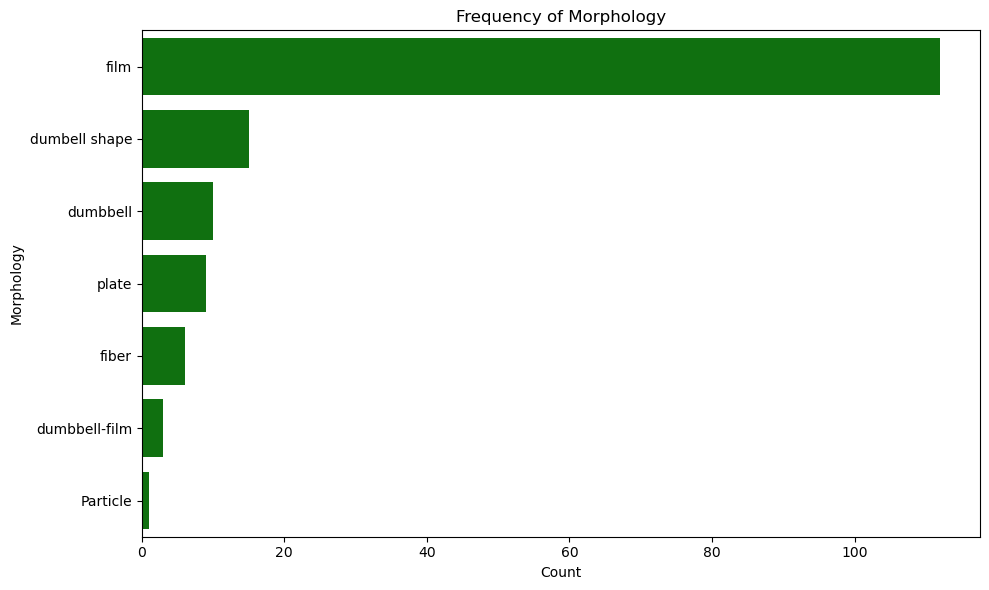

<Figure size 640x480 with 0 Axes>

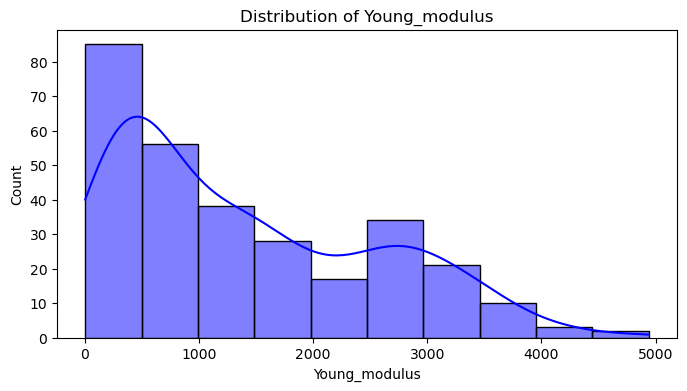

<Figure size 640x480 with 0 Axes>

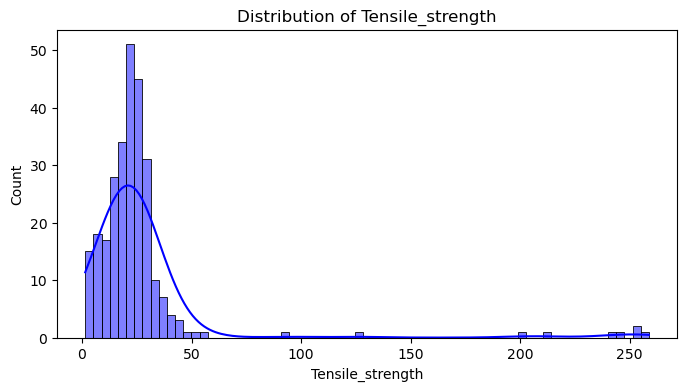

<Figure size 640x480 with 0 Axes>

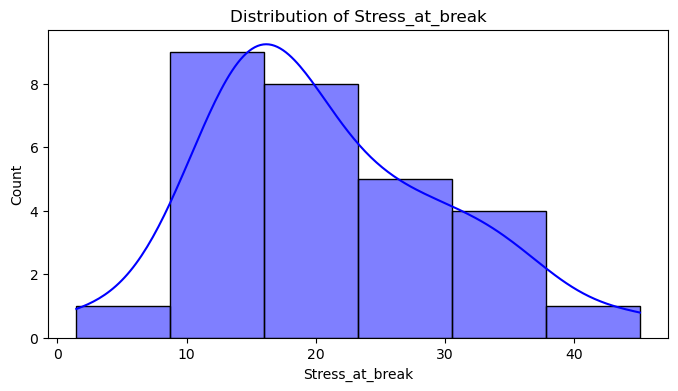

<Figure size 640x480 with 0 Axes>

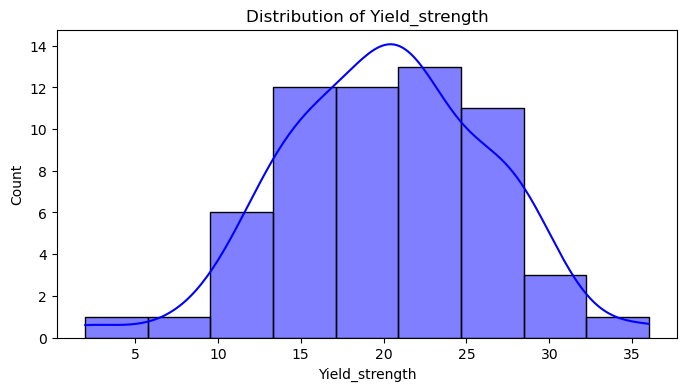

<Figure size 640x480 with 0 Axes>

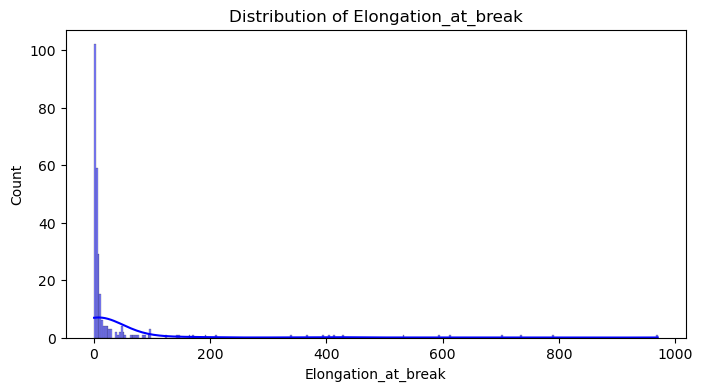

<Figure size 640x480 with 0 Axes>

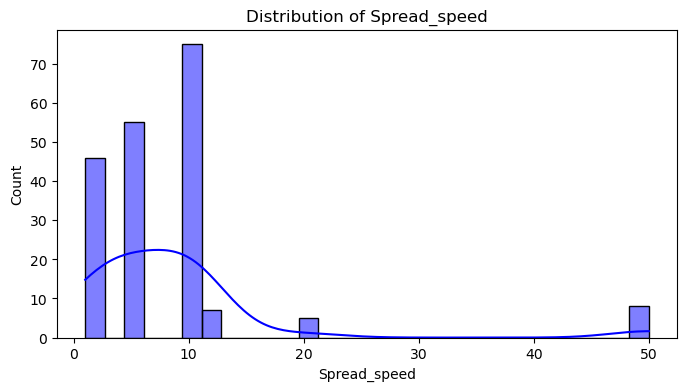

<Figure size 640x480 with 0 Axes>

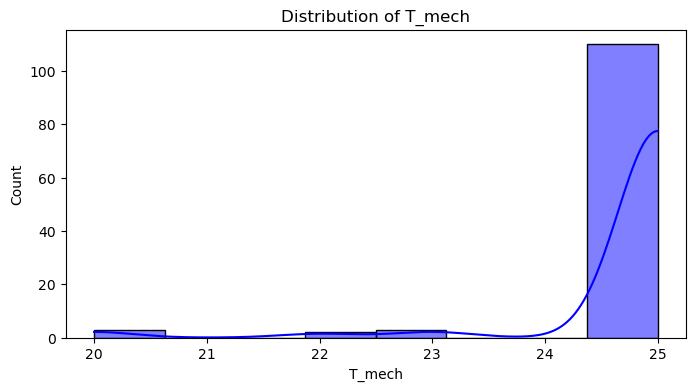

In [22]:
# Columns to plot
mech_cols = ['Morphology', 'Young_modulus', 'Tensile_strength', 'Stress_at_break', 'Yield_strength', 'Elongation_at_break', 'Spread_speed', 'T_mech']

# Make diagrams of distribution for numerical data (blue color) and frequency for categorical data (green color)
for col in mech_cols:
    plt.figure()
    if pd.api.types.is_numeric_dtype(df_mech[col]):
        plt.figure(figsize=(8, 4))
        sns.histplot(df_mech[col], kde=True, color='blue')
        plt.title(f'Distribution of {col}')
    else:
        num_categories = df_mech[col].nunique()
        fig_height = max(6, num_categories * 0.25)

        plt.figure(figsize=(10, fig_height))
        order = df_mech[col].value_counts().index
        sns.countplot(y=col, data=df_mech, order=order, color='green')
        plt.title(f'Frequency of {col}')
        plt.xlabel('Count')
        plt.ylabel(col)
        plt.tight_layout()

    plt.show()



In [23]:
# Create aspect ratio column
df_mech['Aspect_ratio'] = np.where(
    df_mech['Size_diameter'].notna(),
    1,  # If diameter is present → assume AR = 1
    np.where(
        df_mech['Size_length'].notna() & df_mech['Size_width'].notna(),
        df_mech['Size_length'] / df_mech['Size_width'],  # If both length and width exist
        np.nan  # If missing values → return NaN
    )
)

# Merge

In [24]:
# Create Thermal Dataset
df_Thermal = pd.concat([df_physicochem, df_therm.drop(columns=['Study_id', 'Instance'])], axis=1)

# Download Thermal Dataset
# df_Thermal.to_csv('thermal_sclPHA_data.csv', index=False)

# Create Mechanical Dataset
df_Mech = pd.concat([df_physicochem, df_mech.drop(columns=['Study_id', 'Instance'])], axis=1)

# Download Thermal Dataset
# df_Mech.to_csv('mechanical_sclPHA_data.csv', index=False)

# Create United Dataset
df_merged = pd.concat([df_physicochem, df_mech.drop(columns=['Study_id', 'Instance'])], axis=1)
df_merged_fnl = pd.concat([df_merged, df_therm.drop(columns=['Study_id', 'Instance'])], axis=1)

In [25]:
df_merged_fnl = df_merged_fnl.replace(
    ["N/A", "n/a", "NA", "na"],
    np.nan
)

## Fix typos, excl. special characters

In [26]:
def clean_column_name(col):
    col = col.strip().lower()
    col = re.sub(r'[%()]', '', col)        # remove % ( )
    col = re.sub(r'[\/]', '_', col)        # / → _
    col = re.sub(r'\s+', '_', col)         # spaces → _
    col = re.sub(r'[^a-z0-9_]', '', col)   # remove remaining special chars
    col = re.sub(r'_+', '_', col)           # collapse multiple _
    col = col.strip('_')
    return col

def clean_cell_value(val):
    if isinstance(val, str):
        val = val.strip().lower()
        val = re.sub(r'[%()]', '', val)       # remove % ( )
        val = re.sub(r'[\/]', '_', val)       # / → _
        val = re.sub(r'\s+', '_', val)        # spaces → _
        val = re.sub(r'[^a-z0-9_]', '', val)  # remove remaining special chars
        val = re.sub(r'_+', '_', val)         # collapse multiple _
        val = val.strip('_')
    return val

In [27]:
df_merged_fnl.columns = [clean_column_name(c) for c in df_merged_fnl.columns]
df_merged_fnl.head()

,study_id,instance,monomer_a,monomer_b,hb_ratio_mol,hv_ratio_mol,mw_phbv,mn_phbv,density,density_units,...,tm2,td5,tdeg,temperature_units,dhm1,dhm2,dhc1,dhc2,enthaply_units,crystallinity
0,1,1,3HB,NaN,100.0,0.0,1623000.0,1.345000e+06,NaN,NaN,...,NaN,235.0,NaN,celsius,58.0,NaN,NaN,NaN,J/g,NaN
1,2,1,3HB,NaN,100.0,0.0,166000.0,6.384615e+04,NaN,NaN,...,NaN,NaN,NaN,celsius,22.0,NaN,NaN,NaN,cal/g,NaN
2,3,1,3HB,NaN,100.0,0.0,3240000.0,1.940120e+06,NaN,NaN,...,NaN,NaN,NaN,celsius,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2,3HB,3HV,37.0,63.0,1700000.0,7.623318e+05,NaN,NaN,...,NaN,NaN,NaN,celsius,NaN,NaN,NaN,NaN,NaN,NaN
4,3,3,3HB,3HV,22.0,78.0,1830000.0,9.734043e+05,NaN,NaN,...,NaN,NaN,NaN,celsius,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
df_clean = df_merged_fnl.copy()

# apply only to object (string) columns
obj_cols = df_clean.select_dtypes(include='object').columns

df_clean[obj_cols] = df_clean[obj_cols].apply( lambda col: col.map(clean_cell_value) )

In [29]:
df_clean.columns

Index(['study_id', 'instance', 'monomer_a', 'monomer_b', 'hb_ratio_mol',
       'hv_ratio_mol', 'mw_phbv', 'mn_phbv', 'density', 'density_units', 'pdi',
       'additive1', 'additive1_type', 'additive1_name',
       'additive1_percentage_wt', 'additive2', 'additive2_type',
       'additive2_name', 'additive2_percentage_wt',
       'final_formulation_phbv_percentage_wt', 'unnamed_20', 'row_no', 'iso',
       'astm', 't_mech', 't_mech_units', 'spread_speed', 'spread_units',
       'morphology', 'size_diameter', 'size_length', 'size_width',
       'size_thickness', 'size_units', 'young_modulus', 'tensile_strength',
       'stress_at_break', 'yield_strength', 'mechanical_units',
       'elongation_at_break', 'aspect_ratio', 'tg1', 'tg2', 'tc1', 'tc2',
       'tmc', 'tm1', 'tm2', 'td5', 'tdeg', 'temperature_units', 'dhm1', 'dhm2',
       'dhc1', 'dhc2', 'enthaply_units', 'crystallinity'],
      dtype='object')

In [30]:
df_clean.loc[df_clean['additive1_percentage_wt'].isna(), 'additive1_percentage_wt'] = 0
df_clean.loc[df_clean['additive2_percentage_wt'].isna(), 'additive2_percentage_wt'] = 0

df_clean['additive_1'] = df_clean['additive1_percentage_wt'].apply(lambda x: 'yes' if x > 0 else 'no')
df_clean['additive_2'] = df_clean['additive2_percentage_wt'].apply(lambda x: 'yes' if x > 0 else 'no')

df_clean.loc[df_clean['additive_1'] == 'no', 'additive1_type'] = 'no_additive'
df_clean.loc[df_clean['additive_2'] == 'no', 'additive2_type'] = 'no_additive'

## Drop features with more than 30% missing values

In [31]:
df_clean = df_clean.loc[:, df_clean.isna().mean() < 0.70]
df_clean.columns

Index(['study_id', 'instance', 'monomer_a', 'monomer_b', 'hb_ratio_mol',
       'hv_ratio_mol', 'mw_phbv', 'mn_phbv', 'pdi', 'additive1',
       'additive1_type', 'additive1_name', 'additive1_percentage_wt',
       'additive2', 'additive2_type', 'additive2_percentage_wt',
       'final_formulation_phbv_percentage_wt', 'row_no', 'spread_speed',
       'spread_units', 'young_modulus', 'tensile_strength', 'mechanical_units',
       'elongation_at_break', 'tg1', 'tc1', 'tm1', 'tm2', 'td5',
       'temperature_units', 'dhm1', 'enthaply_units', 'crystallinity',
       'additive_1', 'additive_2'],
      dtype='object')

In [32]:
df_clean['additive1_type'].value_counts()

additive1_type
no_additive                                 243
reinforcment_and_stiffening_modifiers       188
plasticizers_and_flexibility_enhancers      133
biofunctional_and_enviromental_additives     18
nucleating_agent                             16
Name: count, dtype: int64

In [ ]:
additive1_mapping = {
    # Plasticizers
    'plasticizer': 'plasticizer',
    'plastisizer': 'plasticizer',

    # Fillers / reinforcements
    'filler': 'filler',
    'reinforcement': 'filler',
    'nucleating_agent': 'filler',
    'impact_modifier': 'filler',

    # Polymer modifiers
    'compatibilizer': 'polymer_modifier',
    'crosslinking_agent': 'polymer_modifier',

    # Stabilizers / functional additives
    'antioxidant': 'stabilizer',
    'stabilizer': 'stabilizer',
    'antimicrobial': 'stabilizer',

    # None
    'not_applicable': 'not_applicable'
}

In [ ]:
df_clean['additive1_type'] = (
    df_clean['additive1_type']
    .map(additive1_mapping)
    .fillna('other')
)

df_clean['additive1_type'].value_counts()

In [33]:
df_clean['additive2_type'].value_counts()

additive2_type
no_additive                                 545
reinforcment_and_stiffening_modifiers        31
plasticizers_and_flexibility_enhancers       16
biofunctional_and_enviromental_additives      6
Name: count, dtype: int64

In [ ]:
additive2_mapping = {
    # Plasticizers
    'plasticizer': 'plasticizer',
    'plastisizer': 'plasticizer',

    # Fillers / reinforcements
    'filler': 'filler',
    'reinforcement': 'filler',

    # Polymer modifiers / blends
    'crosslinking_agent': 'polymer_modifier',
    'compatibilizer': 'polymer_modifier',
    'blend': 'polymer_modifier',

    # Stabilizers (merged due to rarity)
    'antioxidant': 'polymer_modifier',

    # None
    'not_applicable': 'not_applicable'
}

In [ ]:
df_clean['additive2_type'] = (
    df_clean['additive2_type']
    .map(additive2_mapping)
    .fillna('other')
)

df_clean['additive2_type'].value_counts()

In [34]:
df_clean.columns

Index(['study_id', 'instance', 'monomer_a', 'monomer_b', 'hb_ratio_mol',
       'hv_ratio_mol', 'mw_phbv', 'mn_phbv', 'pdi', 'additive1',
       'additive1_type', 'additive1_name', 'additive1_percentage_wt',
       'additive2', 'additive2_type', 'additive2_percentage_wt',
       'final_formulation_phbv_percentage_wt', 'row_no', 'spread_speed',
       'spread_units', 'young_modulus', 'tensile_strength', 'mechanical_units',
       'elongation_at_break', 'tg1', 'tc1', 'tm1', 'tm2', 'td5',
       'temperature_units', 'dhm1', 'enthaply_units', 'crystallinity',
       'additive_1', 'additive_2'],
      dtype='object')

In [35]:
# Select Features and Target
features = ['hb_ratio_mol', 'hv_ratio_mol', 'mw_phbv',
            'mn_phbv', 'pdi', 'additive1_type', 'additive1_percentage_wt', 'additive2_type',
            'additive2_percentage_wt', 'spread_speed', 'young_modulus', 'tensile_strength', 'elongation_at_break', 
            'tg1', 'tc1','tm1', 'td5', 'dhm1', 'crystallinity'
           ]

In [36]:
df_new = df_clean[features]

df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   hb_ratio_mol             595 non-null    float64
 1   hv_ratio_mol             595 non-null    float64
 2   mw_phbv                  381 non-null    float64
 3   mn_phbv                  226 non-null    float64
 4   pdi                      222 non-null    float64
 5   additive1_type           598 non-null    object 
 6   additive1_percentage_wt  598 non-null    float64
 7   additive2_type           598 non-null    object 
 8   additive2_percentage_wt  598 non-null    float64
 9   spread_speed             196 non-null    float64
 10  young_modulus            294 non-null    float64
 11  tensile_strength         275 non-null    float64
 12  elongation_at_break      272 non-null    float64
 13  tg1                      257 non-null    float64
 14  tc1                      3

In [37]:
# Download United Dataset
df_new.to_csv('sclPHA_both_data.csv', index=False)